In [1]:
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

from battery_aging.model_functions import run_rf_gridsearch, permutation_report
from sklearn.inspection import permutation_importance

Dataset = "Stanford"
output_dir = Path("..", "engineered_data")
filename = output_dir / f"processed_battery_features_{Dataset}.pkl"

# Test with old preprocessed dataset
# output_dir = Path("..", "Development")
# filename = output_dir / f"processed_battery_features_v2.pkl"

print(filename)
with open(filename, "rb") as f:
    feature_df = pickle.load(f)

# feature_df = pd.read_pickle(filename)

..\engineered_data\processed_battery_features_Stanford.pkl


In [2]:
feature_groups = {

    # Nur DTW
    "dtw_only": [
        "DTW_V"
    ],

    # Einfache Kurvenabstände
    "curve_distance": [
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V"
    ],

    # Voltage-Features ohne DTW
    "voltage_simple": [
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "SlopeRMSE_V"
    ],

    # Bisheriges Voltage-Core Set
    "voltage_core": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean"
    ],

    # Nur Zeitinformationen
    "time_only": [
        "charge_duration",
        "discharge_duration"
    ],

    # Nur Strominformationen
    "current_only": [
        "I_mean",
        "I_std",
        "DTW_I"
    ],

    # Voltage ohne Zeit
    "voltage_all": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V"
    ],

    # Voltage + Zeit
    "voltage+time": [
        "DTW_V",
        "V_curvature",
        "V_std",
        "V_mean",
        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V",
        "charge_duration",
        "discharge_duration"
    ],

    # Alles
    "full": [
        "DTW_V",
        "DTW_I",

        "V_curvature",
        "V_std",
        "V_mean",
        "V_range",
        "V_slope_mean",
        "V_n_peaks",

        "RMSE_V",
        "AreaDiff_V",
        "Corr_V",
        "MaxDev_V",
        "SlopeRMSE_V",

        "I_mean",
        "I_std",

        "charge_duration",
        "discharge_duration"
    ]
}

In [3]:
results = []
best_models = {}

for name, features in feature_groups.items():

    print(f"Running {name} ...")

    result = run_rf_gridsearch(
        feature_df,
        features
    )

    best_models[name] = result

    results.append({
        "model": name,
        "MAE": result["MAE"],
        "R2": result["R2"],
        "best_params": str(result["best_params"])
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

print(results_df)

Running dtw_only ...
Running curve_distance ...
Running voltage_simple ...
Running voltage_core ...
Running time_only ...
Running current_only ...
Running voltage_all ...
Running voltage+time ...
Running full ...
            model       MAE        R2  \
7    voltage+time  0.003685  0.999125   
8            full  0.003828  0.999099   
4       time_only  0.006576  0.996977   
2  voltage_simple  0.012851  0.985809   
6     voltage_all  0.012668  0.984869   
1  curve_distance  0.015077  0.981892   
3    voltage_core  0.013755  0.981654   
5    current_only  0.019500  0.967201   
0        dtw_only  0.027119  0.955524   

                                         best_params  
7  {'max_depth': 20, 'max_features': 0.8, 'min_sa...  
8  {'max_depth': None, 'max_features': 0.8, 'min_...  
4  {'max_depth': 20, 'max_features': 'sqrt', 'min...  
2  {'max_depth': None, 'max_features': 0.8, 'min_...  
6  {'max_depth': None, 'max_features': 0.8, 'min_...  
1  {'max_depth': 10, 'max_features': 'sqrt', '

In [4]:
top3_models = results_df["model"].head(3)

for model_name in top3_models:

    importance_df = permutation_report(
        best_models[model_name]["best_model"],
        best_models[model_name]["X_test"],
        best_models[model_name]["y_test"]
    )

    print(f"\n===== {model_name} =====")
    print(importance_df)


===== voltage+time =====
               feature  importance       std
0   discharge_duration    1.151511  0.058909
1                DTW_V    0.031927  0.002947
2           AreaDiff_V    0.009004  0.000708
3               RMSE_V    0.001935  0.000138
4               Corr_V    0.001365  0.000107
5               V_mean    0.000581  0.000032
6      charge_duration    0.000172  0.000013
7          SlopeRMSE_V    0.000090  0.000010
8          V_curvature    0.000057  0.000007
9             MaxDev_V    0.000019  0.000004
10               V_std   -0.000074  0.000020

===== full =====
               feature    importance       std
0   discharge_duration  1.265233e+00  0.065327
1                DTW_V  1.728603e-02  0.001639
2           AreaDiff_V  7.356178e-03  0.000668
3                DTW_I  7.235552e-03  0.000470
4               RMSE_V  5.947330e-04  0.000051
5                I_std  3.223399e-04  0.000032
6               Corr_V  2.611982e-04  0.000023
7               V_mean  2.332110e-04  0.

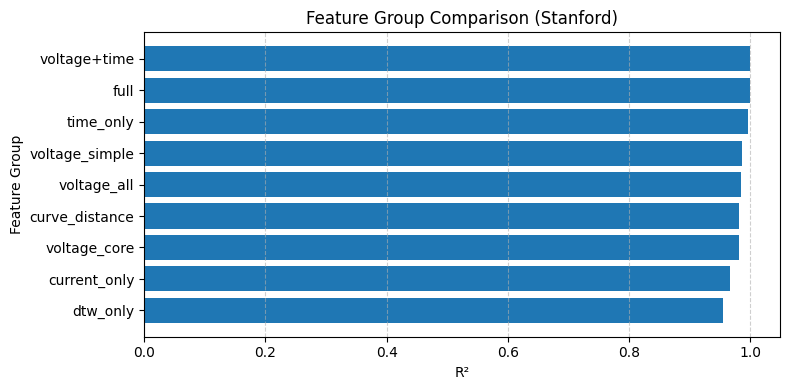

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

# Nach R² sortieren
plot_df = results_df.sort_values("R2", ascending=False)

plt.figure(figsize=(8, 4))

plt.barh(
    plot_df["model"],
    plot_df["R2"]
)

plt.xlabel("R²")
plt.ylabel("Feature Group")
plt.title(f"Feature Group Comparison ({Dataset})")

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.gca().invert_yaxis()

plt.tight_layout()

# Zielordner anlegen
figure_dir = Path("..", "figures")
figure_dir.mkdir(exist_ok=True)

# Grafik speichern
plt.savefig(
    figure_dir / f"feature_group_comparison_{Dataset}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# plt.figure(figsize=(8,4))

# plt.barh(
#     results_df["model"],
#     results_df["R2"]
# )

# plt.xlabel("R²")
# plt.title("Feature Group Comparison")

# plt.grid(axis="x")

# plt.gca().invert_yaxis()

# # Save figure
# plt.tight_layout()


# figure_dir = Path("..", "figures")
# figure_dir.mkdir(exist_ok=True)

# plt.savefig(
#     figure_dir / f"feature_group_comparison_{Dataset}.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

In [7]:
# voltage_features = [
#     "DTW_V",
#     "RMSE_V",
#     "AreaDiff_V",
#     "Corr_V",
#     "MaxDev_V",
#     "SlopeRMSE_V",
#     "V_curvature",
#     "V_std",
#     "V_mean"
# ]

# feature_df[voltage_features].corr()

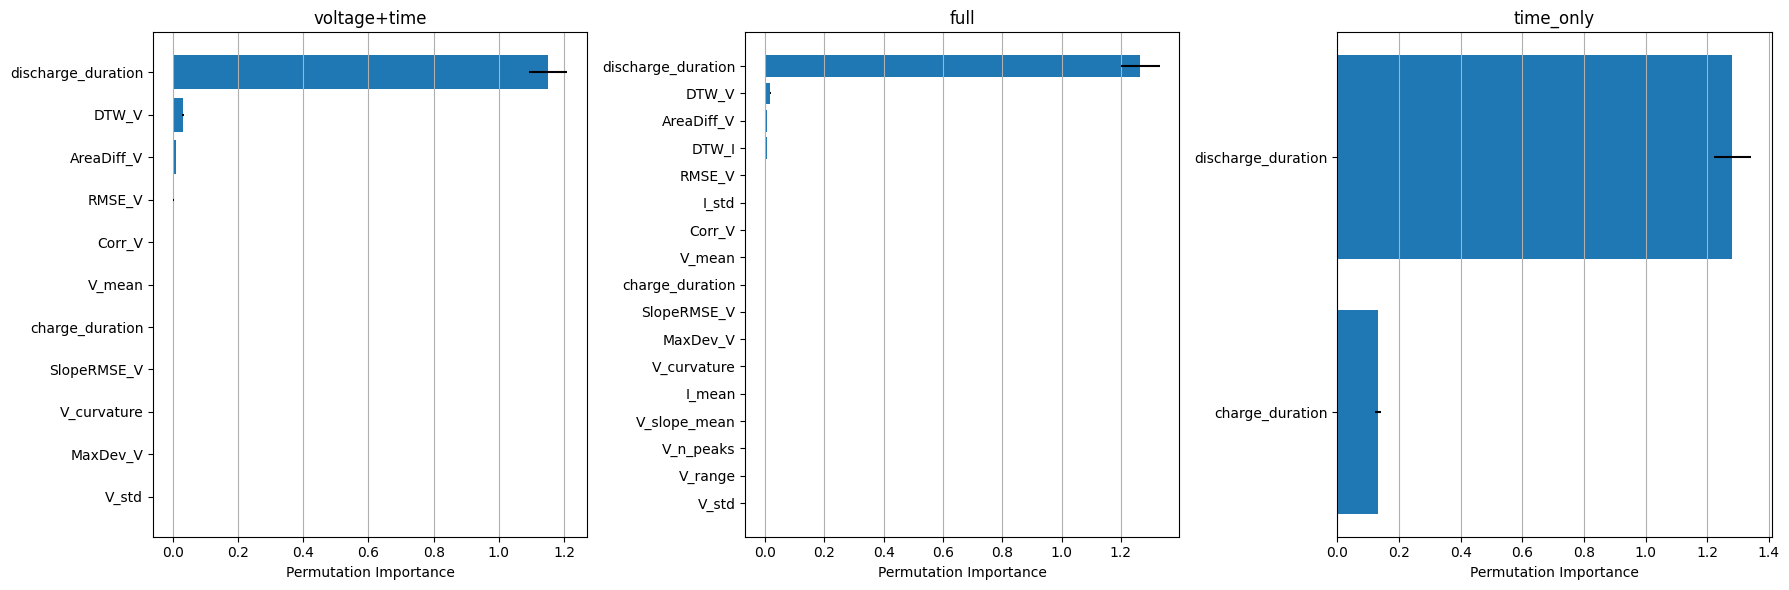

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt

# Top 3 Modelle nach R²
top3_models = results_df.sort_values("R2", ascending=False)["model"].head(3)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, model_name in enumerate(top3_models):

    res = best_models[model_name]

    perm_df = permutation_report(
        res["best_model"],
        res["X_test"],
        res["y_test"]
    )

    perm_df = perm_df.sort_values("importance", ascending=True)

    axes[i].barh(
        perm_df["feature"],
        perm_df["importance"],
        xerr=perm_df["std"]
    )

    axes[i].set_title(model_name)
    axes[i].set_xlabel("Permutation Importance")
    axes[i].grid(axis="x")

plt.tight_layout()

# Save figure
figure_dir = Path("..", "figures")
figure_dir.mkdir(exist_ok=True)

plt.savefig(
    figure_dir / f"permutation_top3_{Dataset}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# importance_df = permutation_report(
#     result["best_model"],
#     result["X_test"],
#     result["y_test"]
# )

# print(importance_df)

In [10]:
# permutation_report("voltage+time")

In [11]:
# permutation_report("full")

In [12]:
# perm_vt = permutation_report("voltage+time")
# perm_full = permutation_report("full")

# perm_vt = perm_vt.sort_values("importance", ascending=True)
# perm_full = perm_full.sort_values("importance", ascending=True)

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# axes[0].barh(
#     perm_vt["feature"],
#     perm_vt["importance"],
#     xerr=perm_vt["std"]
# )
# axes[0].set_title("Voltage + Time")
# axes[0].set_xlabel("Permutation Importance")
# axes[0].grid(axis="x")

# axes[1].barh(
#     perm_full["feature"],
#     perm_full["importance"],
#     xerr=perm_full["std"]
# )
# axes[1].set_title("Full Feature Set")
# axes[1].set_xlabel("Permutation Importance")
# axes[1].grid(axis="x")

# plt.tight_layout()

# # Save figure
# plt.tight_layout()
# plt.savefig(
#     f"figures/permutation_report_vtime_full_{Dataset}.png",
#     dpi=300,
#     bbox_inches="tight"
# )
# plt.show()